
# Free Throw Success Classification (Beginner-Friendly)

This project uses the `combined.csv` dataset (NBA per-game player-season stats from Basketball-Reference) to build **a classification model**.

## Important: What is the target here?
This dataset is **not shot-by-shot free throw attempts** (it does not have a `made/missed` outcome per free throw). Instead it has season-level *rates* like `FT%`.

So we define a clean binary target:

- `target = 1` if a player's **season FT%** is **greater than or equal to the league average FT%** for that same season.
- `target = 0` otherwise.

This gives us a meaningful and well-defined classification task: **is this player an above-average free throw shooter (for that season)?**

We also take care to avoid leakage:
- We **drop `FT%` from the features** (because it's used to build the target).
- We avoid directly using anything that is a trivial re-expression of `FT%`.


# 09. Model Comparison

This notebook loads metrics saved by each model notebook and compares them in a single table and plot.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ARTIFACT_DIR = Path('artifacts')
metric_files = sorted(ARTIFACT_DIR.glob('metrics_*.json'))
print('Found metrics files:', [p.name for p in metric_files])

rows = []
for p in metric_files:
    with open(p) as f:
        rows.append(json.load(f))

df_metrics = pd.DataFrame(rows)
df_metrics = df_metrics.sort_values('f1_weighted', ascending=False)
df_metrics

Found metrics files: ['metrics_03_LogisticRegression_FreeThrow.json', 'metrics_04_KNN_FreeThrow.json', 'metrics_05_SVC_FreeThrow.json', 'metrics_06_RandomForest_FreeThrow.json', 'metrics_07_GradientBoosting_FreeThrow.json', 'metrics_08_ANN_MLP_FreeThrow.json']


,model,accuracy,f1_weighted,f1_macro,precision_weighted,recall_weighted
0,Logistic Regression,0.910372,0.910361,0.910180,0.910363,0.910372
5,ANN (sklearn MLP),0.891669,0.891527,0.891225,0.892132,0.891669
2,SVC (RBF),0.851834,0.851733,0.851374,0.851885,0.851834
4,Gradient Boosting,0.840175,0.840244,0.840050,0.840720,0.840175
3,Random Forest,0.740831,0.740233,0.739391,0.741055,0.740831
1,KNN,0.709983,0.709627,0.708831,0.709809,0.709983


## Compare Accuracy and F1

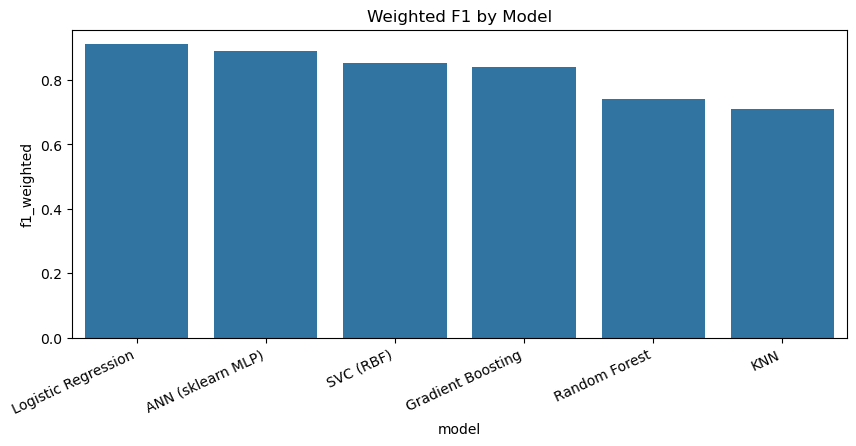

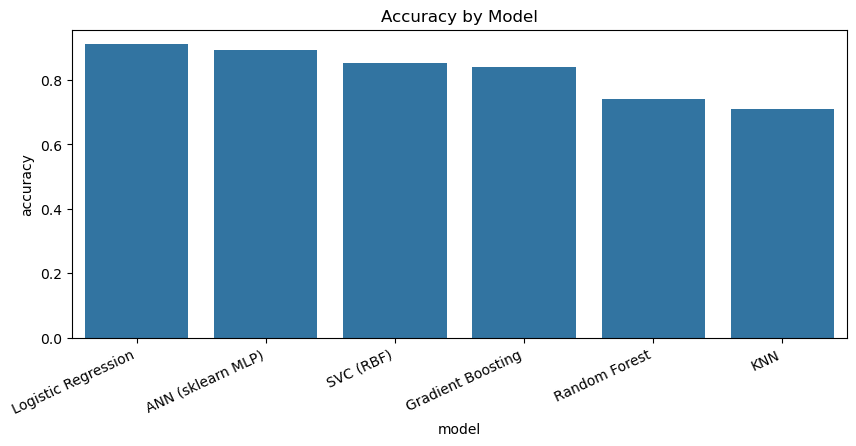

In [2]:
plt.figure(figsize=(10,4))
sns.barplot(data=df_metrics, x='model', y='f1_weighted')
plt.xticks(rotation=25, ha='right')
plt.title('Weighted F1 by Model')
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(data=df_metrics, x='model', y='accuracy')
plt.xticks(rotation=25, ha='right')
plt.title('Accuracy by Model')
plt.show()

## Best Model (Simple Explanation)

The best model is the one with the highest **F1-score** (especially useful if classes are imbalanced).

If accuracy and F1 are close, prefer the model that is:
- simpler to explain (Logistic Regression)
- less likely to overfit (regularized linear models)
- or provides feature importance (Random Forest / Gradient Boosting)
